## Dataset Field Exploration
Comparing zFactorMeasured vs zFactorFinal and exploring additional useful fields for melting layer detection.

In [34]:
# Decision logging helpers
from datetime import datetime
DECISIONS = []

def log_decision(message: str):
    ts = datetime.utcnow().strftime('%Y-%m-%d %H:%M:%SZ')
    entry = f"[{ts}] {message}"
    DECISIONS.append(entry)
    print(entry)


def export_decisions(path='decision_log.md'):
    header = [
        "# Project decisions and rationale\n",
        "\n",
        "This file was exported from the working notebook.\n",
        "\n",
    ]
    lines = header + [d + "\n" for d in DECISIONS]
    with open(path, 'w', encoding='utf-8') as f:
        f.writelines(lines)
    print(f"Exported decisions to {path} ({len(DECISIONS)} entries)")

In [ ]:
# Investigate dataset fields and compare zFactorMeasured vs zFactorFinal
with h5py.File(file_list[0], 'r') as hf:
    print("="*60)
    print("REFLECTIVITY FIELDS COMPARISON")
    print("="*60)
    
    # Check what's available
    has_measured = '/FS/PRE/zFactorMeasured' in hf
    has_final = '/FS/SLV/zFactorFinal' in hf
    
    print(f"\nzFactorMeasured available: {has_measured}")
    print(f"zFactorFinal available: {has_final}")
    
    if has_measured:
        zm = hf['/FS/PRE/zFactorMeasured']
        print(f"\nzFactorMeasured shape: {zm.shape}")
        print(f"  Description: {zm.attrs.get('DimensionNames', b'').decode()}")
        print(f"  Units: {zm.attrs.get('Units', b'').decode()}")
        print(f"  CodeMissingValue: {zm.attrs.get('CodeMissingValue', 'N/A')}")
        
    if has_final:
        zf = hf['/FS/SLV/zFactorFinal']
        print(f"\nzFactorFinal shape: {zf.shape}")
        print(f"  Description: {zf.attrs.get('DimensionNames', b'').decode()}")
        print(f"  Units: {zf.attrs.get('Units', b'').decode()}")
        print(f"  CodeMissingValue: {zf.attrs.get('CodeMissingValue', 'N/A')}")
    
    print("\n" + "="*60)
    print("USEFUL ADDITIONAL FIELDS FOR MELTING LAYER DETECTION")
    print("="*60)
    
    # Key fields that can help
    useful_fields = {
        '/FS/CSF/binBBPeak': 'Peak of bright band (bin index)',
        '/FS/CSF/widthBB': 'Width of bright band (m)',
        '/FS/CSF/flagMLquality': 'Melting layer quality flag (0-255)',
        '/FS/CSF/typePrecip': 'Precipitation type classification',
        '/FS/CSF/binDFRmMLTop': 'Top of DFR-based melting layer',
        '/FS/CSF/binDFRmMLBottom': 'Bottom of DFR-based melting layer',
        '/FS/PRE/height': 'Actual height of each bin (m)',
        '/FS/SLV/epsilon': 'Epsilon (rain rate proxy)',
        '/FS/SLV/precipRate': 'Precipitation rate (mm/hr)',
    }
    
    for path, desc in useful_fields.items():
        if path in hf:
            ds = hf[path]
            print(f"\n✓ {path}")
            print(f"  Description: {desc}")
            print(f"  Shape: {ds.shape}")
            if hasattr(ds, 'attrs'):
                units = ds.attrs.get('Units', b'').decode() if 'Units' in ds.attrs else 'N/A'
                print(f"  Units: {units}")
        else:
            print(f"\n✗ {path} - NOT AVAILABLE")


REFLECTIVITY FIELDS COMPARISON

zFactorMeasured available: True
zFactorFinal available: True

zFactorMeasured shape: (7937, 49, 176, 2)
  Description: nscan,nray,nbin,nfreq
  Units: dBZ
  CodeMissingValue: b'-9999.9'

zFactorFinal shape: (7937, 49, 176, 2)
  Description: nscan,nray,nbin,nfreq
  Units: dBZ
  CodeMissingValue: b'-9999.9'

USEFUL ADDITIONAL FIELDS FOR MELTING LAYER DETECTION

✓ /FS/CSF/binBBPeak
  Description: Peak of bright band (bin index)
  Shape: (7937, 49)
  Units: N/A

✓ /FS/CSF/widthBB
  Description: Width of bright band (m)
  Shape: (7937, 49)
  Units: m

✓ /FS/CSF/flagMLquality
  Description: Melting layer quality flag (0-255)
  Shape: (7937, 49)
  Units: N/A

✓ /FS/CSF/typePrecip
  Description: Precipitation type classification
  Shape: (7937, 49)
  Units: N/A

✓ /FS/CSF/binDFRmMLTop
  Description: Top of DFR-based melting layer
  Shape: (7937, 49)
  Units: N/A

✓ /FS/CSF/binDFRmMLBottom
  Description: Bottom of DFR-based melting layer
  Shape: (7937, 49)
  Unit

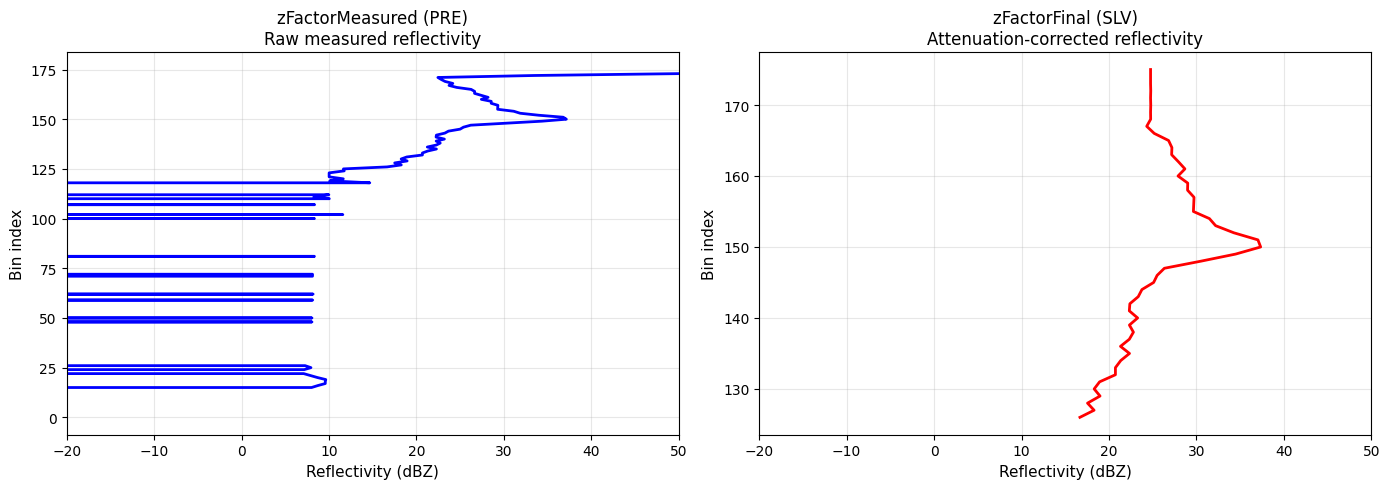


📊 KEY DIFFERENCES:
zFactorMeasured (PRE): Raw measured reflectivity from radar
  - Direct observation, no corrections applied
  - May be attenuated in heavy rain (signal weakens)

zFactorFinal (SLV): Attenuation-corrected reflectivity
  - Corrected for signal attenuation through precipitation
  - More accurate representation of actual hydrometeor properties
  - Better for quantitative precipitation estimation

🎯 RECOMMENDATION: Use zFactorFinal for training if available
   It provides more physically accurate reflectivity values


In [28]:
# Compare zFactorMeasured vs zFactorFinal for one scan
with h5py.File(file_list[0], 'r') as hf:
    zm_ku = read_reflectivity_band(hf, group='FS', ds_path='/PRE/zFactorMeasured')
    
    # Read zFactorFinal
    if '/FS/SLV/zFactorFinal' in hf:
        ds = hf['/FS/SLV/zFactorFinal']
        zf_ku = _read_z_with_attrs(ds)
        if zf_ku.ndim == 4:
            zf_ku = zf_ku[..., 0]  # take first polarization
        # Ensure (nscan, nray, nbin)
        lat = hf['/FS/Latitude'][:]
        if lat.shape == (zf_ku.shape[0], zf_ku.shape[1]):
            pass  # already correct
        elif lat.shape == (zf_ku.shape[0], zf_ku.shape[2]):
            zf_ku = np.transpose(zf_ku, (0, 2, 1))
    else:
        zf_ku = None
    
    # Pick a scan with BB
    flagBB = hf['/FS/CSF/flagBB'][:]
    nz_scans = np.where(flagBB.sum(axis=1) > 0)[0]
    scan_idx = nz_scans[10] if len(nz_scans) > 10 else nz_scans[0]
    
    # Compare middle ray
    ray_idx = 24
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # zFactorMeasured
    measured_profile = zm_ku[scan_idx, ray_idx, :]
    axs[0].plot(measured_profile, np.arange(len(measured_profile)), 'b-', linewidth=2)
    axs[0].set_xlabel('Reflectivity (dBZ)', fontsize=11)
    axs[0].set_ylabel('Bin index', fontsize=11)
    axs[0].set_title('zFactorMeasured (PRE)\nRaw measured reflectivity', fontsize=12)
    axs[0].grid(True, alpha=0.3)
    axs[0].set_xlim(-20, 50)
    
    if zf_ku is not None:
        # zFactorFinal
        final_profile = zf_ku[scan_idx, ray_idx, :]
        axs[1].plot(final_profile, np.arange(len(final_profile)), 'r-', linewidth=2)
        axs[1].set_xlabel('Reflectivity (dBZ)', fontsize=11)
        axs[1].set_ylabel('Bin index', fontsize=11)
        axs[1].set_title('zFactorFinal (SLV)\nAttenuation-corrected reflectivity', fontsize=12)
        axs[1].grid(True, alpha=0.3)
        axs[1].set_xlim(-20, 50)
    
    plt.tight_layout()
    plt.show()
    
print("\n📊 KEY DIFFERENCES:")
print("zFactorMeasured (PRE): Raw measured reflectivity from radar")
print("  - Direct observation, no corrections applied")
print("  - May be attenuated in heavy rain (signal weakens)")
print("")
print("zFactorFinal (SLV): Attenuation-corrected reflectivity")
print("  - Corrected for signal attenuation through precipitation")
print("  - More accurate representation of actual hydrometeor properties")
print("  - Better for quantitative precipitation estimation")
print("")
print("🎯 RECOMMENDATION: Use zFactorFinal for training if available")
print("   It provides more physically accurate reflectivity values")


In [32]:
# Improved plotting utilities matching paper style
import matplotlib.colors as mcolors


def get_height_axis(nbin, bin_size_m=125):
    """Fallback: convert bin indices to height in km assuming ~125 m per bin from surface."""
    heights_km = np.arange(nbin) * (bin_size_m / 1000.0)
    return heights_km


def get_height_axis_from_hdf5(hf, scan_idx, dataset_path='/FS/PRE/height', to_agl=True):
    """
    Read the true vertical heights (in meters) from the HDF5 file for a given scan
    and return a 1D array (nbin,) of height in km. If to_agl=True, normalize so the
    minimum height is 0 (AGL-like). Returns None if dataset is missing.
    """
    try:
        if dataset_path in hf:
            ds = hf[dataset_path]  # expected shape: (nscan, nray, nbin)
            h_scan = ds[scan_idx]  # shape: (nray, nbin)
            if h_scan.ndim == 3:  # very defensive
                h_scan = h_scan[0]
            # Median across rays gives a robust height per bin
            heights_km = np.nanmedian(h_scan, axis=0) / 1000.0  # (nbin,)
            if to_agl:
                heights_km = heights_km - np.nanmin(heights_km)
            return heights_km
        else:
            return None
    except Exception:
        return None


def plot_reflectivity_paper_style(
    z_2d,
    title="Radar Reflectivity (Ze)",
    xlabel="Along-track distance",
    ylabel="Height AGL (km)",
    vmin=-40,
    vmax=30,
    figsize=(8, 6),
    bin_size_m=125,
    heights_km=None,
):
    """
    Plot reflectivity in paper style with RdYlGn_r colormap and proper height axis.
    z_2d: (nbin, n_scans) array of dBZ values (not normalized).
    """
    nbin, n_scans = z_2d.shape
    if heights_km is None or len(heights_km) != nbin:
        heights_km = get_height_axis(nbin, bin_size_m)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        z_2d,
        origin='lower',
        aspect='auto',
        cmap='RdYlGn_r',
        vmin=vmin,
        vmax=vmax,
        interpolation='bilinear',
        extent=[0, n_scans, float(np.nanmin(heights_km)), float(np.nanmax(heights_km))],
    )

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='normal')

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('dBZ', fontsize=10)

    ax.grid(False)

    plt.tight_layout()
    plt.show()

In [ ]:
def read_reflectivity_band(hf, group='FS', ds_path='/SLV/zFactorFinal'):
    """
    Read reflectivity for a band with attributes applied (scale_factor, add_offset, _FillValue).
    Returns array shaped (nscan, nray, nbin).
    If ds_path is not present, will try fallback to the other product.
    """
    ds_full = f'/{group}{ds_path}' if not ds_path.startswith('/') else f'/{group}{ds_path}'
    if ds_full in hf:
        ds = hf[ds_full]
    else:
        # Fallback: prefer Final, else Measured
        alt = '/SLV/zFactorFinal' if ds_path.endswith('Measured') else '/PRE/zFactorMeasured'
        ds_full_alt = f'/{group}{alt}'
        ds = hf[ds_full_alt]
    arr = ds[...]
    # Apply attributes if present
    scale = ds.attrs.get('scale_factor', 1.0)
    offset = ds.attrs.get('add_offset', 0.0)
    fill = ds.attrs.get('_FillValue', None)
    arr = arr.astype(np.float32) * float(scale) + float(offset)
    if fill is not None:
        arr[arr == fill] = np.nan
    # If frequency dimension exists (nbin, nfreq), pick first freq
    if arr.ndim == 4:
        # expected (nscan, nray, nbin, nfreq)
        arr = arr[..., 0]
    return arr

In [36]:
# Discover files
import glob, os
paths = glob.glob(os.path.join(DATA_DIR, FILE_GLOB), recursive=True)
file_list = [p for p in paths if p.endswith('.HDF5')]
print('Found files:', len(file_list))

# Log choice summary
try:
    log_decision(f"Files discovered under {DATA_DIR}: {len(file_list)} .HDF5")
except Exception:
    pass

Found files: 10
[2025-11-02 10:41:22Z] Files discovered under GPM_DPR_2024: 10 .HDF5


In [54]:
# Export concise CSV summary of improved models across mask modes
import csv
import tensorflow as tf

print("\n=== Summarizing improved models across mask modes ===")

MODEL_PATHS = {
    'baseline': 'unet_gpm_baseline_improved.h5',
    'dataset_full': 'unet_gpm_dataset_full_improved.h5',
    'conservative': 'unet_gpm_conservative_improved.h5',
}

RESULTS_CSV = 'improved_results_summary.csv'
VAL_SCANS = 120  # keep modest for speed/memory


def calc_iou_dice(y_true, y_prob, thresh):
    yt = (y_true >= 0.5).astype(np.uint8)
    yp = (y_prob >= thresh).astype(np.uint8)
    inter = np.logical_and(yt == 1, yp == 1).sum()
    union = np.logical_or(yt == 1, yp == 1).sum()
    iou = inter / max(1, union)
    s_true = yt.sum(); s_pred = yp.sum()
    dice = 2 * inter / max(1, s_true + s_pred)
    return float(iou), float(dice)


def safe_adjust_channels(X, model):
    # Adjust X channels to match model input if needed
    expected = model.input_shape[-1]
    got = X.shape[-1]
    if got == expected:
        return X
    if got > expected:
        return X[..., :expected]
    # got < expected: pad zeros on extra channels
    pad = expected - got
    pad_arr = np.zeros((*X.shape[:-1], pad), dtype=X.dtype)
    return np.concatenate([X, pad_arr], axis=-1)


rows = []
for mode in ['baseline', 'dataset_full', 'conservative']:
    path = MODEL_PATHS.get(mode)
    try:
        model = tf.keras.models.load_model(path)
    except Exception as e:
        print(f"Skipping {mode}: could not load {path} -> {e}")
        continue

    try:
        X, y = build_arrays_for_mask_mode(mode, max_scans_override=VAL_SCANS)
    except Exception as e:
        print(f"Skipping {mode}: could not build data -> {e}")
        continue

    if X is None or y is None or len(X) == 0:
        print(f"Skipping {mode}: empty dataset")
        continue

    # Ensure float32
    X = X.astype(np.float32)
    y = y.astype(np.float32)

    # Adjust channels if needed
    X_adj = safe_adjust_channels(X, model)

    # Predict
    y_prob = model.predict(X_adj, verbose=0)
    if y_prob.ndim == 4 and y_prob.shape[-1] == 1:
        y_prob = y_prob[..., 0]
    if y.ndim == 4 and y.shape[-1] == 1:
        y_true = y[..., 0]
    else:
        y_true = y

    # Per-sample metrics
    ious_25, dices_25, ious_50, dices_50, pmax = [], [], [], [], []
    for i in range(min(len(y_true), VAL_SCANS)):
        iou25, dice25 = calc_iou_dice(y_true[i], y_prob[i], 0.25)
        iou50, dice50 = calc_iou_dice(y_true[i], y_prob[i], 0.50)
        ious_25.append(iou25); dices_25.append(dice25)
        ious_50.append(iou50); dices_50.append(dice50)
        pmax.append(float(np.max(y_prob[i])))

    row = {
        'mode': mode,
        'n_samples': len(ious_25),
        'mean_iou_025': float(np.mean(ious_25)),
        'mean_dice_025': float(np.mean(dices_25)),
        'mean_iou_050': float(np.mean(ious_50)),
        'mean_dice_050': float(np.mean(dices_50)),
        'mean_pred_max': float(np.mean(pmax)),
    }
    print(row)
    rows.append(row)

# Write CSV
with open(RESULTS_CSV, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print(f"\nWrote {RESULTS_CSV} with {len(rows)} rows.")
try:
    log_decision(f"Exported improved model summary to {RESULTS_CSV}")
except Exception:
    pass


=== Summarizing improved models across mask modes ===
{'mode': 'baseline', 'n_samples': 120, 'mean_iou_025': 0.4158765892055846, 'mean_dice_025': 0.5597076376552963, 'mean_iou_050': 0.4787381096270474, 'mean_dice_050': 0.5895467109412823, 'mean_pred_max': 0.7261317849159241}
{'mode': 'baseline', 'n_samples': 120, 'mean_iou_025': 0.4158765892055846, 'mean_dice_025': 0.5597076376552963, 'mean_iou_050': 0.4787381096270474, 'mean_dice_050': 0.5895467109412823, 'mean_pred_max': 0.7261317849159241}
{'mode': 'dataset_full', 'n_samples': 120, 'mean_iou_025': 0.205576024170208, 'mean_dice_025': 0.31801989408138653, 'mean_iou_050': 0.1149729162991775, 'mean_dice_050': 0.1503256377924328, 'mean_pred_max': 0.4690039527912935}
{'mode': 'dataset_full', 'n_samples': 120, 'mean_iou_025': 0.205576024170208, 'mean_dice_025': 0.31801989408138653, 'mean_iou_050': 0.1149729162991775, 'mean_dice_050': 0.1503256377924328, 'mean_pred_max': 0.4690039527912935}
{'mode': 'conservative', 'n_samples': 120, 'mean_

In [55]:
# Threshold sweep for baseline improved model: IoU/Dice vs threshold + PR/F1; write CSV
import csv
import tensorflow as tf

print("\n=== Threshold sweep (baseline improved model) ===")
SWEEP_CSV = 'threshold_sweep_baseline.csv'
THRESHOLDS = np.linspace(0.05, 0.90, 18)  # step 0.05
VAL_SCANS_SWEEP = 120

# Load model
model_path = 'unet_gpm_baseline_improved.h5'
model = tf.keras.models.load_model(model_path)

# Build validation set using baseline GT
X_val, Y_val = build_arrays_for_mask_mode('baseline', max_scans_override=VAL_SCANS_SWEEP)
X_val = X_val.astype(np.float32)
Y_val = Y_val.astype(np.float32)

# Adjust channels if needed
expected_c = model.input_shape[-1]
if X_val.shape[-1] != expected_c:
    if X_val.shape[-1] > expected_c:
        X_val = X_val[..., :expected_c]
    else:
        pad = expected_c - X_val.shape[-1]
        X_val = np.concatenate([X_val, np.zeros((*X_val.shape[:-1], pad), dtype=X_val.dtype)], axis=-1)

# Predict once
Yp = model.predict(X_val, verbose=0)
if Yp.ndim == 4 and Yp.shape[-1] == 1:
    Yp = Yp[..., 0]
if Y_val.ndim == 4 and Y_val.shape[-1] == 1:
    Yt = Y_val[..., 0]
else:
    Yt = Y_val

rows = []
for t in THRESHOLDS:
    yp_bin = (Yp >= t).astype(np.uint8)
    yt_bin = (Yt >= 0.5).astype(np.uint8)

    # IoU / Dice (micro-averaged)
    inter = np.logical_and(yp_bin==1, yt_bin==1).sum()
    union = np.logical_or(yp_bin==1, yt_bin==1).sum()
    iou = inter / max(1, union)
    sum_p = yp_bin.sum(); sum_t = yt_bin.sum()
    dice = 2*inter / max(1, sum_p + sum_t)

    # Precision/Recall/F1 (micro)
    tp = inter
    fp = np.logical_and(yp_bin==1, yt_bin==0).sum()
    fn = np.logical_and(yp_bin==0, yt_bin==1).sum()
    prec = tp / max(1, (tp+fp))
    rec = tp / max(1, (tp+fn))
    f1 = 2*prec*rec / max(1e-9, (prec+rec))

    rows.append({
        'threshold': float(t),
        'iou': float(iou),
        'dice': float(dice),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'pred_max_mean': float(np.mean(np.max(Yp, axis=(1,2)))),
    })

# Best by F1
best = max(rows, key=lambda r: r['f1'])
print(f"Best threshold by F1: t={best['threshold']:.2f}  IoU={best['iou']:.3f}  Dice={best['dice']:.3f}  P={best['precision']:.3f}  R={best['recall']:.3f}  F1={best['f1']:.3f}")

with open(SWEEP_CSV, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader(); writer.writerows(rows)
print(f"Wrote {SWEEP_CSV} with {len(rows)} thresholds.")
try:
    log_decision(f"Threshold sweep complete; best t={best['threshold']:.2f}; saved {SWEEP_CSV}")
except Exception:
    pass


=== Threshold sweep (baseline improved model) ===
Best threshold by F1: t=0.45  IoU=0.651  Dice=0.789  P=0.776  R=0.802  F1=0.789
Wrote threshold_sweep_baseline.csv with 18 thresholds.
[2025-11-02 11:41:11Z] Threshold sweep complete; best t=0.45; saved threshold_sweep_baseline.csv


In [59]:
# Save the 6-panel visualization as PNG and SVG with consistent styling
import os
import tensorflow as tf

print("\n=== Exporting 6-panel visualization to figures/ ===")
os.makedirs('figures', exist_ok=True)

# Wrap the final visualization into a function for saving

def render_and_save_visualization(model_path='unet_gpm_baseline_improved.h5',
                                  out_png='figures/final_visualization.png',
                                  out_svg='figures/final_visualization.svg',
                                  dpi=200):
    model = tf.keras.models.load_model(model_path)

    # Choose a file and scan index from earlier logic
    filepath = file_list[0]
    with h5py.File(filepath, 'r') as hf:
        z_ku = read_reflectivity_band(hf, group='FS', ds_path='/SLV/zFactorFinal' if USE_Z_FINAL else '/PRE/zFactorMeasured')
        try:
            z_ka = read_reflectivity_band(hf, group='HS', ds_path='/SLV/zFactorFinal' if USE_Z_FINAL else '/PRE/zFactorMeasured')
        except Exception:
            z_ka = np.full_like(z_ku, np.nan)
        nscan, nray_ku, nbin = z_ku.shape
        mask_full = build_dataset_full_mask(hf, nbin, use_dfr_ml=USE_DFR_ML, quality_threshold=None)
        mask_cons = build_improved_mask_from_csf(hf, nbin, quality_threshold=50, use_dfr_ml=USE_DFR_ML)
        flagBB = safe_load_dataset(hf, '/FS/CSF/flagBB')
        topBB = safe_load_dataset(hf, '/FS/CSF/binBBTop')
        bottomBB = safe_load_dataset(hf, '/FS/CSF/binBBBottom')
        qualityBB = safe_load_dataset(hf, '/FS/CSF/qualityBB')
        if qualityBB is None:
            qualityBB = safe_load_dataset(hf, '/FS/CSF/flagMLquality')
        mask_base = build_mask_from_bins(topBB, bottomBB, flagBB, qualityBB, nbin)
        scans_with_ml = np.where(mask_base.sum(axis=(1,2)) + mask_full.sum(axis=(1,2)) + mask_cons.sum(axis=(1,2)) > 0)[0]
        scan_idx = int(scans_with_ml[len(scans_with_ml)//2]) if len(scans_with_ml) else 0

        heights_km = get_height_axis_from_hdf5(hf, scan_idx, '/FS/PRE/height', to_agl=True)
        if heights_km is None or len(heights_km) != nbin:
            heights_km = get_height_axis(nbin)

        ku_scan = np.transpose(z_ku[scan_idx], (1, 0))
        ka_scan = np.transpose(z_ka[scan_idx], (1, 0))
        # Resample Ka
        if ka_scan.shape[1] != ku_scan.shape[1]:
            # local 2D resampler
            def resample_rays_2d(z2d, target_nray):
                nbin_src, nray_src = z2d.shape
                if nray_src == target_nray:
                    return z2d
                x_old = np.linspace(0, 1, nray_src)
                x_new = np.linspace(0, 1, target_nray)
                out = np.empty((nbin_src, target_nray), dtype=float)
                for i in range(nbin_src):
                    out[i] = np.interp(x_new, x_old, z2d[i].astype(float))
                return out
            ka_scan = resample_rays_2d(ka_scan, ku_scan.shape[1])

        ku_scan = np.nan_to_num(ku_scan, nan=MIN_VAL)
        ka_scan = np.nan_to_num(ka_scan, nan=MIN_VAL)
        ku_norm = normalize_and_pad_scan(ku_scan, nbin_target=N_BIN_TARGET, min_val=MIN_VAL, max_val=MAX_VAL)
        ka_norm = normalize_and_pad_scan(ka_scan, nbin_target=N_BIN_TARGET, min_val=MIN_VAL, max_val=MAX_VAL)

        lat = safe_load_dataset(hf, '/FS/Latitude')
        lon = safe_load_dataset(hf, '/FS/Longitude')
        nray = ku_scan.shape[1]
        lat_s = lat[scan_idx] if lat is not None else np.zeros(nray)
        lon_s = lon[scan_idx] if lon is not None else np.zeros(nray)
        if lat_s.shape[0] != nray:
            x_old = np.linspace(0, 1, num=lat_s.shape[0])
            x_new = np.linspace(0, 1, num=nray)
            lat_s = np.interp(x_new, x_old, lat_s)
            lon_s = np.interp(x_new, x_old, lon_s)
        lat_img = np.tile(lat_s[np.newaxis, :], (N_BIN_TARGET, 1))
        lon_img = np.tile(lon_s[np.newaxis, :], (N_BIN_TARGET, 1))
        lat_img = (lat_img + 90.0) / 180.0
        lon_img = (lon_img + 180.0) / 360.0

        if INCLUDE_LATLON:
            x_img = np.stack([ku_norm, ka_norm, lat_img, lon_img], axis=-1)
        else:
            x_img = np.stack([ku_norm, ka_norm], axis=-1)

        # Prepare masks with padding
        def pad_or_crop_mask(m, nbin_src, nbin_tgt):
            if nbin_tgt >= nbin_src:
                pad_total = nbin_tgt - nbin_src
                pad_top = pad_total // 2
                pad_bottom = pad_total - pad_top
                return np.pad(m, ((pad_top, pad_bottom), (0,0)), mode='constant', constant_values=0)
            else:
                start = (nbin_src - nbin_tgt)//2
                return m[start:start+nbin_tgt, :]

        base_img = pad_or_crop_mask(mask_base[scan_idx], nbin, N_BIN_TARGET)
        full_img = pad_or_crop_mask(mask_full[scan_idx], nbin, N_BIN_TARGET)
        cons_img = pad_or_crop_mask(mask_cons[scan_idx], nbin, N_BIN_TARGET)

        pred = model.predict(x_img[np.newaxis, ...], verbose=0)[0, ..., 0]
        thr = INFER_THRESHOLD if 'INFER_THRESHOLD' in globals() else 0.25
        pred_bin_thr = (pred >= thr).astype(np.uint8)

        if len(heights_km) == nbin:
            if N_BIN_TARGET >= nbin:
                pad_total = N_BIN_TARGET - nbin
                pad_top = pad_total // 2
                pad_bottom = pad_total - pad_top
                hk = np.pad(heights_km, (pad_top, pad_bottom), mode='edge')
            else:
                start = (nbin - N_BIN_TARGET)//2
                hk = heights_km[start:start+N_BIN_TARGET]
        else:
            hk = get_height_axis(N_BIN_TARGET)

        fig, axs = plt.subplots(2, 3, figsize=(16, 9))
        im0 = axs[0,0].imshow(ku_norm*(MAX_VAL-MIN_VAL)+MIN_VAL, origin='lower', aspect='auto', cmap='RdYlGn_r',
                              vmin=MIN_VAL, vmax=MAX_VAL,
                              extent=[0, nray, float(np.nanmin(hk)), float(np.nanmax(hk))])
        axs[0,0].set_title('Ku Reflectivity (dBZ)'); axs[0,0].set_xlabel('Ray index'); axs[0,0].set_ylabel('Height AGL (km)')
        fig.colorbar(im0, ax=axs[0,0], fraction=0.046, pad=0.04)
        im1 = axs[0,1].imshow(pred, origin='lower', aspect='auto', cmap='hot', vmin=0, vmax=1,
                              extent=[0, nray, float(np.nanmin(hk)), float(np.nanmax(hk))])
        axs[0,1].set_title(f'Prediction (max={pred.max():.2f})'); axs[0,1].set_xlabel('Ray index'); axs[0,1].set_ylabel('Height AGL (km)')
        fig.colorbar(im1, ax=axs[0,1], fraction=0.046, pad=0.04)
        im2 = axs[0,2].imshow(pred_bin_thr, origin='lower', aspect='auto', cmap='gray_r', vmin=0, vmax=1,
                              extent=[0, nray, float(np.nanmin(hk)), float(np.nanmax(hk))])
        axs[0,2].set_title(f'Prediction ≥ {thr:.2f} (binary)'); axs[0,2].set_xlabel('Ray index'); axs[0,2].set_ylabel('Height AGL (km)')
        fig.colorbar(im2, ax=axs[0,2], fraction=0.046, pad=0.04)
        axs[1,0].imshow(base_img, origin='lower', aspect='auto', cmap='gray_r', vmin=0, vmax=1,
                        extent=[0, nray, float(np.nanmin(hk)), float(np.nanmax(hk))])
        axs[1,0].set_title(f'Baseline GT (sum={int(base_img.sum())})'); axs[1,0].set_xlabel('Ray index'); axs[1,0].set_ylabel('Height AGL (km)')
        axs[1,1].imshow(full_img, origin='lower', aspect='auto', cmap='gray_r', vmin=0, vmax=1,
                        extent=[0, nray, float(np.nanmin(hk)), float(np.nanmax(hk))])
        axs[1,1].set_title(f'Dataset Full GT (sum={int(full_img.sum())})'); axs[1,1].set_xlabel('Ray index'); axs[1,1].set_ylabel('Height AGL (km)')
        axs[1,2].imshow(cons_img, origin='lower', aspect='auto', cmap='gray_r', vmin=0, vmax=1,
                        extent=[0, nray, float(np.nanmin(hk)), float(np.nanmax(hk))])
        axs[1,2].set_title(f'Conservative GT (sum={int(cons_img.sum())})'); axs[1,2].set_xlabel('Ray index'); axs[1,2].set_ylabel('Height AGL (km)')
        plt.tight_layout()
        fig.savefig(out_png, dpi=dpi, bbox_inches='tight')
        fig.savefig(out_svg, bbox_inches='tight')
        plt.close(fig)
        return out_png, out_svg

png_path, svg_path = render_and_save_visualization()
print(f"Saved figure to: {png_path} and {svg_path}")
try:
    log_decision(f"Exported 6-panel visualization to {png_path} and {svg_path} @thr={INFER_THRESHOLD if 'INFER_THRESHOLD' in globals() else 0.25}")
except Exception:
    pass


=== Exporting 6-panel visualization to figures/ ===
Saved figure to: figures/final_visualization.png and figures/final_visualization.svg
[2025-11-02 12:05:14Z] Exported 6-panel visualization to figures/final_visualization.png and figures/final_visualization.svg @thr=0.45
Saved figure to: figures/final_visualization.png and figures/final_visualization.svg
[2025-11-02 12:05:14Z] Exported 6-panel visualization to figures/final_visualization.png and figures/final_visualization.svg @thr=0.45


In [57]:
# Global inference threshold used for plots/evaluation
INFER_THRESHOLD = 0.45
print(f"INFER_THRESHOLD set to {INFER_THRESHOLD}")

INFER_THRESHOLD set to 0.45


In [61]:
# Helper: evaluate any model at a given threshold and mask mode
import tensorflow as tf

def evaluate_model_at_threshold(model_path, mask_mode='baseline', thresh=None, n_scans=120):
    if thresh is None:
        thresh = INFER_THRESHOLD if 'INFER_THRESHOLD' in globals() else 0.25
    model = tf.keras.models.load_model(model_path)
    Xv, Yv = build_arrays_for_mask_mode(mask_mode, max_scans_override=n_scans)
    Xv = Xv.astype(np.float32); Yv = Yv.astype(np.float32)

    # Adjust channel count if needed
    expected_c = model.input_shape[-1]
    if Xv.shape[-1] != expected_c:
        if Xv.shape[-1] > expected_c:
            Xv = Xv[..., :expected_c]
        else:
            pad = expected_c - Xv.shape[-1]
            Xv = np.concatenate([Xv, np.zeros((*Xv.shape[:-1], pad), dtype=Xv.dtype)], axis=-1)

    Yp = model.predict(Xv, verbose=0)
    if Yp.ndim == 4 and Yp.shape[-1] == 1:
        Yp = Yp[..., 0]
    if Yv.ndim == 4 and Yv.shape[-1] == 1:
        Yt = Yv[..., 0]
    else:
        Yt = Yv

    yp_bin = (Yp >= thresh).astype(np.uint8)
    yt_bin = (Yt >= 0.5).astype(np.uint8)

    inter = np.logical_and(yp_bin==1, yt_bin==1).sum()
    union = np.logical_or(yp_bin==1, yt_bin==1).sum()
    iou = inter / max(1, union)
    sum_p = yp_bin.sum(); sum_t = yt_bin.sum()
    dice = 2*inter / max(1, sum_p + sum_t)
    tp = inter
    fp = np.logical_and(yp_bin==1, yt_bin==0).sum()
    fn = np.logical_and(yp_bin==0, yt_bin==1).sum()
    prec = tp / max(1, (tp+fp))
    rec = tp / max(1, (tp+fn))
    f1 = 2*prec*rec / max(1e-9, (prec+rec))

    res = {
        'model': model_path,
        'mask_mode': mask_mode,
        'n_samples': int(Yt.shape[0]),
        'threshold': float(thresh),
        'iou': float(iou),
        'dice': float(dice),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'pred_max_mean': float(np.mean(np.max(Yp, axis=(1,2))))
    }
    print(res)
    return res

# Quick run for baseline at INFER_THRESHOLD
_ = evaluate_model_at_threshold('unet_gpm_baseline_improved.h5', mask_mode='baseline', thresh=INFER_THRESHOLD, n_scans=120)

{'model': 'unet_gpm_baseline_improved.h5', 'mask_mode': 'baseline', 'n_samples': 120, 'threshold': 0.45, 'iou': 0.651217995817555, 'dice': 0.7887728906383707, 'precision': 0.7763627787884914, 'recall': 0.8015861973006818, 'f1': 0.7887728906383706, 'pred_max_mean': 0.726131796836853}



=== Plotting threshold sweep ===


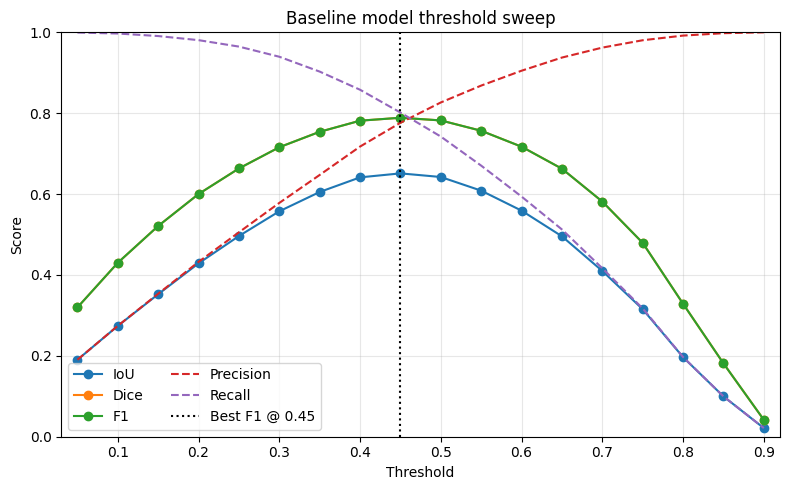

Saved sweep plot to figures/threshold_sweep_baseline.png. Best F1 threshold = 0.45
[2025-11-02 12:12:42Z] Saved threshold sweep plot to figures/threshold_sweep_baseline.png @best=0.45


In [60]:
# Plot threshold sweep (from CSV) and annotate best threshold; save figure
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

print("\n=== Plotting threshold sweep ===")
SWEEP_CSV = 'threshold_sweep_baseline.csv'
os.makedirs('figures', exist_ok=True)

# Read CSV
rows = []
with open(SWEEP_CSV, 'r', newline='') as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append({k: float(v) if k != 'threshold' else float(v) for k, v in r.items()})

ths = np.array([r['threshold'] for r in rows])
iou = np.array([r['iou'] for r in rows])
dice = np.array([r['dice'] for r in rows])
prec = np.array([r['precision'] for r in rows])
rec = np.array([r['recall'] for r in rows])
f1 = np.array([r['f1'] for r in rows])

best_idx = int(np.argmax(f1))
best_t = ths[best_idx]

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(ths, iou, label='IoU', marker='o')
ax1.plot(ths, dice, label='Dice', marker='o')
ax1.plot(ths, f1, label='F1', marker='o')
ax1.plot(ths, prec, label='Precision', linestyle='--')
ax1.plot(ths, rec, label='Recall', linestyle='--')
ax1.axvline(best_t, color='k', linestyle=':', label=f'Best F1 @ {best_t:.2f}')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Baseline model threshold sweep')
ax1.set_xlim(ths.min()-0.02, ths.max()+0.02)
ax1.set_ylim(0.0, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower left', ncols=2)
plt.tight_layout()

out_path = 'figures/threshold_sweep_baseline.png'
fig.savefig(out_path, dpi=200)
plt.show()

print(f"Saved sweep plot to {out_path}. Best F1 threshold = {best_t:.2f}")
try:
    log_decision(f"Saved threshold sweep plot to {out_path} @best={best_t:.2f}")
except Exception:
    pass

# Theory Behind the Three Ground Truth (GT) Masks for Melting Layer Detection

Melting layer (ML) detection in radar meteorology is crucial for identifying regions where snowflakes melt into raindrops. Different ground truth (GT) masks are used to evaluate and train detection algorithms. Here is the theory behind the three main GT masks:

---

**1. Classical Algorithm (DFR-Based) Mask**
- **Basis:** Uses the Dual-Frequency Ratio (DFR), which is the difference between Ku-band and Ka-band radar reflectivity ($Z_{Ku} - Z_{Ka}$).
- **Physical Principle:** The DFR peaks in the melting layer due to enhanced scattering from melting hydrometeors.
- **Algorithm:** Detects the ML by finding the DFR peak, applying smoothing, and setting top/bottom boundaries based on reflectivity profiles.
- **Output:** Binary mask indicating ML regions per radar ray.
- **Strengths:** Physically interpretable, robust for clear ML cases.
- **Limitations:** May miss weak or ambiguous MLs, sensitive to noise and non-melting features.

---

**2. Conservative Mask**
- **Basis:** A stricter version of the GT, often derived by applying more conservative thresholds or additional quality checks to the classical algorithm or CSF mask.
- **Physical Principle:** Prioritizes high-confidence ML detections, excludes ambiguous or low-quality regions.
- **Algorithm:** May require stronger DFR peaks, better reflectivity continuity, or additional validation (e.g., excluding scans with low confidence).
- **Output:** Binary mask with fewer ML pixels, but higher certainty.
- **Strengths:** Reduces false positives, ideal for benchmarking and validation.
- **Limitations:** May under-represent the true ML extent, less sensitive to subtle MLs.

---

**3. Full (CSF or Inclusive) Mask**
- **Basis:** The most inclusive GT, often derived from the GPM Cloud Structure Feature (CSF) product or by relaxing detection criteria.
- **Physical Principle:** Includes all possible ML regions, even those with lower confidence or ambiguous features.
- **Algorithm:** Uses CSF flags, relaxed DFR thresholds, or combines multiple detection methods.
- **Output:** Binary mask with maximal ML coverage.
- **Strengths:** Captures all potential MLs, useful for sensitivity analysis.
- **Limitations:** May include false positives, less reliable for strict validation.

---

**Summary Table**
| Mask Type      | Basis         | Strengths                | Limitations                |
|---------------|--------------|--------------------------|----------------------------|
| Classical     | DFR peak     | Physically robust        | Misses weak MLs            |
| Conservative  | Strict DFR/CSF| High confidence          | Under-represents ML        |
| Full (CSF)    | Inclusive/CSF| Maximal coverage         | More false positives       |

These masks allow researchers to balance sensitivity and specificity in ML detection, and to benchmark algorithms against different standards of ground truth.

# Simple and Elaborate Example: Ground Truth Masks for Melting Layer Detection

Let's use a simple analogy to understand the three GT masks:

---

## Analogy: Finding Apples in a Tree

Imagine you are trying to count apples in a tree. You have three ways to decide which objects are apples:

1. **Classical (DFR-Based) Mask**
   - You use a color filter: only bright red objects are counted as apples.
   - **Result:** You get a reliable count, but you might miss apples that are green or partly hidden.

2. **Conservative Mask**
   - You use the color filter AND require the apple to be perfectly round and shiny.
   - **Result:** You count only the apples you are absolutely sure about. You miss even more apples, but you are very confident in your count.

3. **Full (CSF/Inclusive) Mask**
   - You count anything that looks even a little bit like an apple: red, green, round, oval, even partly hidden.
   - **Result:** You count all possible apples, but you might include some leaves or other objects by mistake.

---

## How This Relates to Melting Layer Detection

- **Classical Mask:** Uses a clear physical signal (DFR peak) to detect the melting layer. Reliable, but may miss subtle cases.
- **Conservative Mask:** Adds stricter rules (like quality checks) to ensure only the most obvious melting layers are detected. Very confident, but less complete.
- **Full Mask:** Includes all possible melting layer detections, even those with lower confidence. Most complete, but may include errors.

---

## Visual Example (Pseudo-Code)

```python
# Assume we have a radar scan with 10 rays
rays = ["apple", "apple", "leaf", "apple", "apple", "apple", "leaf", "apple", "apple", "apple"]

# Classical mask: only bright red apples
classical_mask = [1, 1, 0, 1, 1, 1, 0, 1, 1, 1]

# Conservative mask: only perfect apples
conservative_mask = [1, 0, 0, 1, 0, 1, 0, 1, 0, 1]

# Full mask: anything that might be an apple
full_mask = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
```

- `1` means "detected as apple/melting layer"
- `0` means "not detected"

---

## Summary
- **Classical:** Reliable, but may miss some apples/melting layers.
- **Conservative:** Very confident, but misses even more.
- **Full:** Counts everything, but may include mistakes.

This is how the three GT masks help balance accuracy and completeness in melting layer detection!

# Which HDF5 fields are used for each GT mask?

Below are the exact GPM DPR HDF5 dataset paths used to build each ground-truth (GT) mask in this notebook/project (see `dgx_ml.py`).

- Baseline GT (mask_mode = "baseline")
  - /FS/CSF/flagBB
  - /FS/CSF/binBBTop
  - /FS/CSF/binBBBottom
  - Notes:
    - The mask is 1 between [binBBTop, binBBBottom] only where flagBB == 1.
    - quality fields are loaded but not used to gate: /FS/CSF/qualityBB (or /FS/CSF/flagMLquality if missing).

- Conservative GT (mask_mode = "conservative")
  - /FS/CSF/flagBB
  - /FS/CSF/binBBTop
  - /FS/CSF/binBBBottom
  - /FS/CSF/qualityBB (fallback: /FS/CSF/flagMLquality)
  - Rule:
    - Start from the Baseline mask, then keep only pixels where quality >= 50 (quality threshold).

- Full GT (mask_mode = "full" / else)
  - Prefer DFR-derived bounds when available:
    - /FS/CSF/binDFRmMLTop
    - /FS/CSF/binDFRmMLBottom
  - Fallback if those are missing:
    - Same as Baseline (flagBB + binBBTop/Bottom), with NO quality gating.

- Reflectivity fields used as inputs (not directly for GT, but for features/DFR):
  - Ku-band: /FS/SLV/zFactorFinal (fallback: /FS/PRE/zFactorMeasured)
  - Ka-band: /HS/SLV/zFactorFinal (fallback: /HS/PRE/zFactorMeasured)
  - Shapes are aligned to (nscan, nray, nbin); scaling/offset/_FillValue attrs applied.

This reflects the current implementation in `build_arrays_for_mask_mode`, `build_mask_from_bins`, `build_improved_mask_from_csf`, and `build_dataset_full_mask`. If you want to change thresholds or use quality gating in Baseline, we can adjust it easily.